# Week 8 - Linear Disciminant Analysis and Optimization

* FDA (2 classes)
    * Compute the class means (in PCA space)
    * Compute the within-class scatter matrix $\mathbf{S}_W$ and between-class scatter matrix $\mathbf{S}_B$
    * Compute the projection vector $\mathbf{w}$
    * Compute and plot the 1D projection of the data
    * Compute the class separation of the projected values
* LDA (3 classes)
    * Compute the within-class scatter matrix $\mathbf{S}_W$ and between-class scatter matrix $\mathbf{S}_B$
    * Compute the projection matrix $\mathbf{W}$
    * Compute and plot the 2D projection of the data
    * Compute the 2D LDA projection of the original 64D data 
* Constrained Optimization
    * Reformulate the problem as a maximization problem
    * Write out the Lagrangian function
    * Compute the gradients with respects to $x_1, x_2$, Lagrange multiplier $\lambda$ and the KKT multiplier $\mu$
    * Compute the optimum

In [2]:
# Dependencies
import numpy as np
import scipy
from sklearn.datasets import load_digits, make_swiss_roll
from sklearn.decomposition import PCA 
import matplotlib.pyplot as plt 
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns; sns.set(); sns.set_palette('bright')

## Data
As usual, we'll be working with a dataset of handwritten digits. 
Let visualise some examples.

In [3]:
# We're using a subset of two classes for now
digits = load_digits(n_class=2)

In [4]:
# Handy plotting functions

def plot_examples():
    show_num = 4
    _, axes = plt.subplots(1, show_num)
    images_and_labels = list(zip(digits.images, digits.target))
    for ax, (image, label) in zip(axes[:], images_and_labels[:show_num]):
        ax.set_axis_off()
        ax.imshow(image, cmap=plt.cm.gray_r, interpolation='nearest')
        ax.set_title('Label: %i' % label)

def plot_scatter(data, target, alpha=0.5, legend=True,w=None):
    scatter = plt.scatter(data[:, 0], data[:, 1], c=target, edgecolor='none', alpha=alpha, cmap='rainbow')
    if legend:
        plt.legend(*scatter.legend_elements(), loc="upper right", title="Targets")
    plt.xlabel('Component 1')
    plt.ylabel('Component 2')

    if w is not None:
        # Define the range of x values based on the scatter plot data
        x_values = np.linspace(np.min(data[:, 0]), np.max(data[:, 0]), 100)
        
        # Calculate corresponding y values based on the line equation: w0 + w1*x1 + w2*x2 = 0 => x2 = -(w0 + w1*x1) / w2
        y_values = w[1] * x_values + w[0]

        # Plot the line
        plt.plot(x_values, y_values, color='red', label='Decision boundary')
    #plt.show()
    
def plot_scatter3d(data, targets, view_point=(25, 45), alpha=0.5, legend=True):
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    scatter = ax.scatter(data[:,0], data[:,1], data[:,2], c=targets, cmap="rainbow", alpha=alpha)
    if legend:
        plt.legend(*scatter.legend_elements(), loc="upper right", title="Targets")
    ax.view_init(*view_point) # <- change viewpoint here
    ax.set_xlabel('Component 1')
    ax.set_ylabel('Component 2')
    ax.set_zlabel('Component 3')
    plt.show()

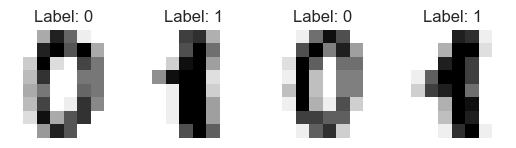

In [5]:
plot_examples()

In [6]:
# We can get a 2D version of the data using PCA
pca = PCA(n_components=2)
X = pca.fit_transform(digits.data) # this is the representation, we'll be working with
t = digits.target

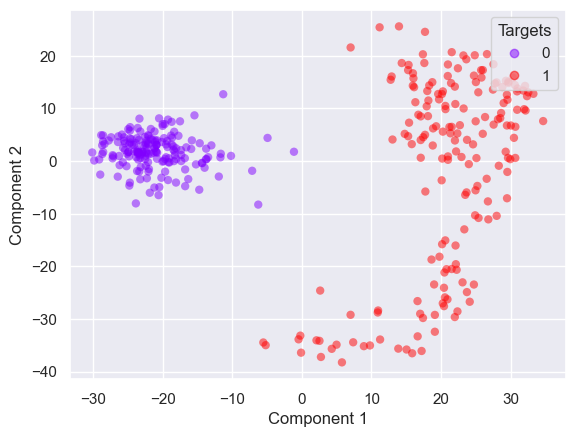

In [7]:
# Let's plot all the data in 2D
plot_scatter(X, t)

## 1) Fisher Discriminant Analysis (FDA)


### 1.1) Compute the class means (in PCA space)

In [8]:
def class_means(X, t):
    classes = np.unique(t)
    ms = list(np.zeros(len(classes)))
    Ns = list(np.zeros(len(classes)))
    N = len(X)
    for n in range(N):
        Ns[t[n]] += 1
        ms[t[n]] += X[n]
    
    return_array = []
    for m, n in zip(ms, Ns):
        return_array.append(m/n)
    return return_array

m1, m2 = class_means(X, t)
print(f"Mean for class 0: {m1}")
print(f"Mean for class 1: {m2}")

Mean for class 0: [-21.14447038   1.75335626]
Mean for class 1: [20.67975675 -1.71482096]


### 1.2) Compute the within-class scatter matrix $\mathbf{S}_W$ and between-class scatter matrix $\mathbf{S}_B$
Use eq (4.27) and (4.28) from textbook for computing $\mathbf{S}_B$ and $\mathbf{S}_W$ respectively

In [9]:
def scatter_matrix(X, t):
    m1, m2 = class_means(X, t)
    S_B = np.outer((m2 - m1), (m2 - m1))

    S_W = 0
    N = len(X)
    for n in range(N):
        xn = X[n]
        if t[n] == 0:
            S_W += np.outer((xn - m1), (xn - m1))
        else:
            S_W += np.outer((xn - m2), (xn - m2))
    
    return S_B, S_W

S_B, S_W = scatter_matrix(X, t)

print(f"S_B = \n{S_B}")
print(f"S_W = \n{S_W}")

S_B = 
[[1749.26597493 -145.05383207]
 [-145.05383207   12.02825328]]
S_W = 
[[15041.33444706 13053.23317691]
 [13053.23317691 64127.63085988]]


### 1.3) Compute the projection vector $\mathbf{w}$
Hint: Use eq. (4.30) from textbook. You can use `np.linalg.pinv` and `np.linalg.eig` for computing the pseudo-inverse and eigenvectors, respectively. Also, remember to ensure that $||w||_2 = 1$

In [10]:
def projection_vector(S_W, m1, m2):
    S_W_i = np.linalg.pinv(S_W)
    w = S_W_i @ (m2 - m1)
    return w / np.linalg.norm(w)

w = projection_vector(S_W, m1, m2)
print(f"w = \n{w}")

w = 
[ 0.97678792 -0.21420868]


### 1.4) Compute and plot the 1D projection of the data
Hint: You can use `seaborn.displot` for a nice visualisation

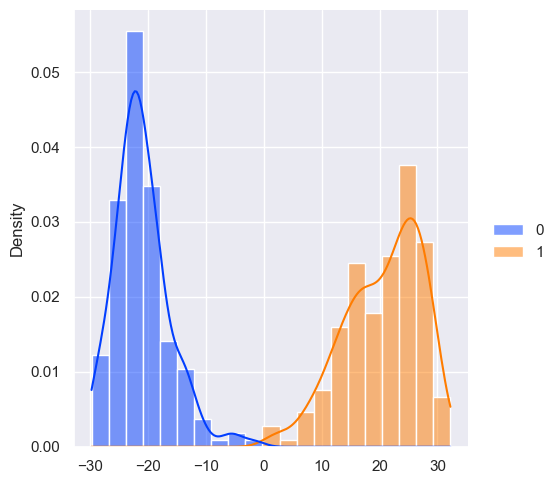

In [11]:
import seaborn as sns

Y = np.inner(w, X)
Y0 = []
Y1 = []
N = len(Y)
for n in range(N):
    if t[n] == 0:
        Y0.append(Y[n])
    else:
        Y1.append(Y[n])


sns.displot(data=(Y0, Y1), kde=True, bins=21, stat="density")

### 1.5) Compute the class separation of the projected values

In [12]:
def class_separation(w, m1, m2):
    return w.T @ (m2 - m1)

class_separation(w, m1, m2)

41.596313499803756

## 2) Linear Discriminant Analysis (LDA)

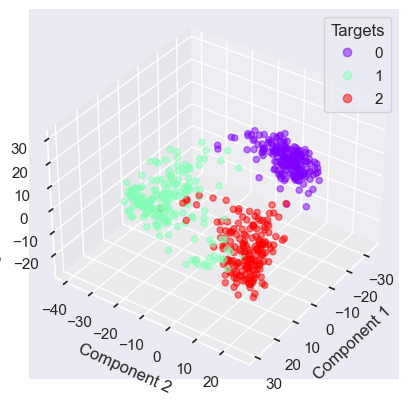

In [13]:
# Data
n_class = 3
digits = load_digits(n_class=n_class)
pca = PCA(n_components=3)
X = pca.fit_transform(digits.data)
t = digits.target

plot_scatter3d(X, t, view_point=(35,35))

### 2.1) Compute the within-class scatter matrix $\mathbf{S}_W$ and between-class scatter matrix $\mathbf{S}_B$
See section 4.1.6 in the textbook or Lecture 15 (slide 17)

In [14]:
def LDA_scatter_matrix(X, t):
    m = X.mean(axis=0)
    means = class_means(X, t)

    K = len(means)
    N = len(X)

    # https://stackoverflow.com/questions/28663856/how-do-i-count-the-occurrence-of-a-certain-item-in-an-ndarray
    unique, counts = np.unique(t, return_counts=True)
    Ns = dict(zip(unique, counts))
    
    S_W = 0
    S_B = 0
    for k in range(K):
        S_B += Ns[k] * np.outer(means[k] - m, means[k] - m)
        
        for n in range(N):
            if t[n] == k:
                S_W += np.outer(X[n] - means[k], X[n] - means[k])
    
    return S_B, S_W

S_B, S_W = LDA_scatter_matrix(X, t)
print(f"S_B = \n{S_B}")
print(f"S_W = \n{S_W}")

S_B = 
[[168102.96379892 -19720.58431368 -19025.65776937]
 [-19720.58431368  63939.56120416 -18774.45509042]
 [-19025.65776937 -18774.45509042   9313.72198557]]
S_W = 
[[27768.47732321 19720.58431368 19025.65776937]
 [19720.58431368 51486.18362507 18774.45509042]
 [19025.65776937 18774.45509042 56959.24511402]]


### 2.2) Compute the projection matrix $\mathbf{W}$
choose D'=2 (see lecture 15 slide 17 to understand D')

In [15]:
def projection_matrix(S_W, S_B):
    D_prime = 2
    eigvals, eigvecs = np.linalg.eig(np.linalg.pinv(S_W) @ S_B)
    sorted_indices = np.argsort(eigvals)[::-1]
    eigvals = eigvals[sorted_indices]
    eigvecs = eigvecs[:, sorted_indices]
    W = eigvecs[:, :D_prime]
    return W

W = projection_matrix(S_W, S_B)
print(f"W = \n{W}")

W = 
[[ 0.91734684 -0.13270419]
 [-0.33360306 -0.82474716]
 [-0.21721826  0.54971058]]


### 2.3) Compute and plot the 2D projection of the data

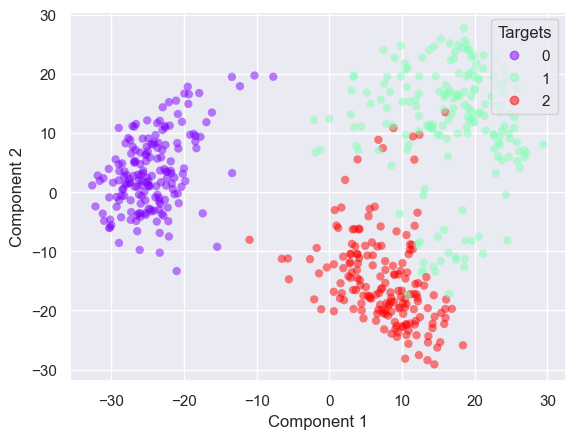

In [16]:
y = X @ W
plot_scatter(y, t)

### 2.4) Compute and plot the 2D LDA projection of the original 64D data 

In [17]:
# Data
n_class = 3
digits = load_digits(n_class=n_class)
X = digits.data
t = digits.target

c:\Users\henri\AppData\Local\Programs\Python\Python310\lib\site-packages\matplotlib\collections.py:193: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)


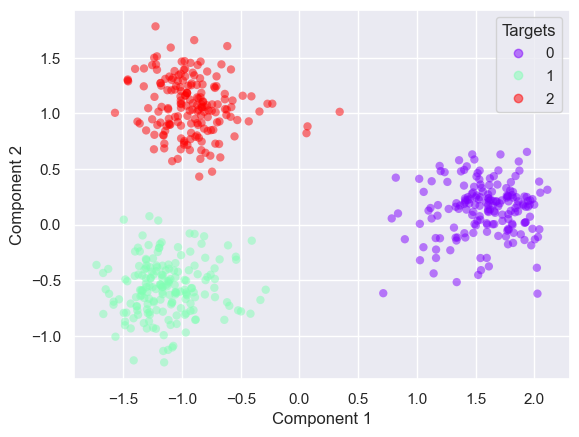

In [18]:
# Compute means
means = class_means(X, t)

# compute within class and between-class scatter matrices
S_B, S_W = LDA_scatter_matrix(X, t)

# Compute eigenvalues and eigenvectors, sort them and select top 2 eigenvectors
W = projection_matrix(S_W, S_B)

# perform projection
y = X @ W

plot_scatter(y, t)

Comment on the general utility of the projection as compared to PCA

LDA is generally better to do classification of data given labels, meaning that it has to be supervised. PCA on the otherhand does not need labels, but simply seperates data based on variance with no regard to labels.

# 3) Constrained Optimization
 
Consider the problem

minimize $f_{min}(x_1, x_2)$

subject to $ x_1 + x_2 \leq 4 
\quad \text{ and } \quad x_1 + 4x_2 = 5 
$
where $f_{min}(x_1, x_2) = (x_1 - 3)^2 + (x_2 - 2)^2$

## 3.1) Reformulate the problem as a canonical maximization problem
_Use the form described in the end of "Pattern Recognition and Machine Learning" Appendix E._

_NB: There is an error in appendix E: $h(x) \leq 0$, not $h(x) \geq 0$._

We have two constraints, an equality constraint:
$$
g(x_1, x_2) = x_1 + 4x_2 - 5 = 0
$$

and an inequality constraint:
$$
h(x_1, x_2) = x_1 + x_2 - 4 \leq 0
$$

To minimize the "min" function, which corresponds to a "max" function:
$$
f_{max} (x_1, x_2) = - f_{min}(x_1, x_2) = - (x_1 - 3)^2 - (x_2 - 2)^2
$$

## 3.2) Write out the Lagrangian function
_Use Equation (E.12) in "Pattern Recognition and Machine Learning" Appendix E., and write out all variables_

This gives the lagrangian function
\begin{align*}
L(x, \lambda, \mu) &= f(x_{1}, x_{2}) + \lambda g(x_{1}, x_{2}) + \mu h(x_{1}, x_{2})\\
&= - (x_{1} - 3)^{2} - (x_{2} - 2)^{2} + \lambda (x_{1} + 4x_{2} - 5) + \mu(x_{1} + x_{2} - 4)
\end{align*}

## 3.3) Compute the gradients with respects to $x_1, x_2$, lagrange multiplier $\lambda$ and the KKT multiplier $\mu$

\begin{align*}
\nabla L &= 
\begin{bmatrix}
\frac{\partial L}{\partial x_{1}} \\
\frac{\partial L}{\partial x_{2}} \\
\frac{\partial L}{\partial \lambda} \\
\frac{\partial L}{\partial \mu}
\end{bmatrix}\\
&= 
\begin{bmatrix}
- (2(x_{1} - 3) \cdot 1) + \lambda + \mu \\
- (2(x_{2} - 2) \cdot 1) + 4\lambda + \mu \\
x_{1} + 4x_{2} - 5 \\
x_{1} + x_{2} - 4
\end{bmatrix}\\
&=
\begin{bmatrix}
-2x_{1} + 6 + \lambda + \mu \\
-2x_{2} + 4 + 4\lambda + \mu \\
x_{1} + 4x_{2} - 5 \\
x_{1} + x_{2} - 4
\end{bmatrix}
\end{align*}

### 3.4) Compute the optimum
_Hint: Set it up as a system of linear equations and solve it using Gaussian Elimination (e.g. using `scipy.linalg.solve`)._

Follow these steps:

1. **Assume the inequality constraint $ h(x) $ is inactive.**  
   - Set its Lagrange multiplier to zero ($ \mu = 0 $).  
   - Include only the equality constraint $ g(x) = 0 $ in your formulation.  
   - Construct the system of equations from the KKT conditions:  
     $$
     \nabla f(x) + \lambda \nabla g(x) = 0, \quad g(x) = 0
     $$
   - Solve for $ x_1, x_2, \lambda $ using `scipy.linalg.solve`.

2. **Check the inequality constraint.**  
   - Evaluate $ h(x_1, x_2) $.  
   - If $ h(x_1, x_2) < 0 $, the constraint is inactive — keep this as your final solution.

3. **If the inequality is violated** ($ h(x_1, x_2) > 0 $):  
   - Reformulate the problem assuming $ h(x) $ is **active** ($ h(x) = 0 $).  
   - Include both constraints in the Lagrangian:  
     $$
     \mathcal{L}(x_1, x_2, \lambda, \mu) = f(x_1, x_2) + \lambda g(x_1, x_2) + \mu h(x_1, x_2)
     $$
   - Construct the corresponding system of equations:
     $$
     \nabla f(x) + \lambda \nabla g(x) + \mu \nabla h(x) = 0, \quad g(x) = 0, \quad h(x) = 0
     $$
   - Solve for $ x_1, x_2, \lambda, \mu $ using `scipy.linalg.solve`.

_The correct optimum is the solution that satisfies all constraints and yields the lowest $ f(x) $._


Finding the gradients of $f(x)$ and $g(x)$
$$
\nabla f =
\begin{bmatrix}
-2x_{1} + 6 \\
-2x_{2} + 4
\end{bmatrix}
$$
$$
\nabla g =
\begin{bmatrix}
1 \\
4
\end{bmatrix}
$$

In [ ]:
# Your code here
# 1.
a = np.array([[-2, 0, 1], 
              [0, -2, 4],
              [1, 4, 0]])
b = np.array([[-6],
              [-4],
              [5]])

x = scipy.linalg.solve(a, b)
x1 = x[0][0]
x2 = x[1][0]
lam = x[2][0]
print(f"x1 = {x1}")
print(f"x2 = {x2}")
print(f"lambda = {lam}")

# 2.
print(f"h(x) = {x1 + x2 - 4} <= 0 (seems good to me)")
print(f"g(x) = {x1 + 4*x2 - 5}")
print(f"f_min(x) = {(x1 - 3)**2 + (x2 - 2)**2}")

# 3. No need

x1 = 2.6470588235294117
x2 = 0.5882352941176471
lambda = -0.7058823529411765
h(x) = -0.7647058823529411 <= 0 (seems good to me)
g(x) = 0.0
f_min(x) = 2.117647058823529
